In [1]:
import numpy as np
import torch
import torch.nn as nn
import time

from scipy.integrate import solve_ivp as sp_solve_ivp
from sklearn.preprocessing import MinMaxScaler
from tqdm.auto import tqdm
from ftnode.utils import set_global_seed
from ftnode.node import (
    FTNODE, FeluSigmoidMLP,
     GeluSigmoidMLPfeaturized
)
from typing import List

import matplotlib.pyplot as plt
plt.style.use('default')
plt.rcParams['font.family']= 'serif'

device = 'cpu'
seed = 1234
set_global_seed(seed=seed,deterministic=True)
# random_state = 67

[Seed] Deterministic mode enabled (may reduce speed).


In [2]:
def budworm_ode(t,x,r,k):
    return r*x*(1-x/k) - x**2 / (1+x**2)

In [3]:
from sympy import symbols, Eq, solve, simplify
r_sym, k_sym = symbols('r k', positive=True)
a = r_sym / k_sym
b = -r_sym
c = (k_sym + r_sym) / k_sym
d = -r_sym
p = (3 * a * c - b**2) / (3 * a**2)
q = (2 * b**3 - 9 * a * b * c + 27 * a**2 * d) / (27 * a**3)

D = -(4 * p**3 + 27 * q**2)
D = simplify(D)

D_fixed = D.subs(r_sym, 0.56)
r1_sol, r2_sol = solve(Eq(D_fixed, 0), k_sym)

In [4]:
n_control = 51
n_traj = 51

r_val=0.56
# Ensure us values are floats
us = np.linspace(float(r1_sol) - 2, float(r2_sol) + 2, n_control)
x0s = np.linspace(0.1, 10, n_traj)



In [5]:
t_max = 10
n_colloc = 801


Xs = []
Us = []
t = np.linspace(0,t_max, n_colloc)

for ui in tqdm(us):
    for x0 in x0s:
        sol = sp_solve_ivp(
            budworm_ode,
            t_span = [0,t_max],
            y0 = np.array(x0).reshape(-1),
            t_eval = np.linspace(0,t_max,n_colloc),
            args = (r_val,ui,)
        )

        Xs.append(sol.y.T)
        Us.append([ui])

Xs = np.array(Xs)
Us = np.array(Us)

  0%|          | 0/51 [00:00<?, ?it/s]

In [6]:
scaler = MinMaxScaler(feature_range=(0, 1))
Xs_scaled = scaler.fit_transform(Xs.reshape(-1, 1)).reshape(-1, n_colloc, 1)

In [7]:
dXs = np.zeros_like(Xs)
T = t[np.newaxis, :, np.newaxis]
X_diff = Xs_scaled[:, 2:, :] - Xs_scaled[:, :-2, :]
T_diff = T[:, 2:, :] - T[:, :-2, :]

dXs[:, 1:-1, :] = X_diff / T_diff
dXs[:, 0, :] = (Xs_scaled[:, 1, :] - Xs_scaled[:, 0, :]) / (T[:, 1, :] - T[:, 0, :])
dXs[:, -1, :] = (Xs_scaled[:, -1, :] - Xs_scaled[:, -2, :]) / (T[:, -1, :] - T[:, -2, :])

In [8]:
dX_tensor = [torch.tensor(dxi, dtype=torch.float32, device=device) for dxi in dXs]
X_tensor = [torch.tensor(xi, dtype=torch.float32, device=device) for xi in Xs_scaled]
U_tensor = [torch.tensor(ui, dtype=torch.float32, device=device) for ui in Us]
T_tensor = [torch.tensor(t, dtype=torch.float32, device=device) for _ in range(len(Xs))]

In [9]:
class GradDataset(torch.utils.data.Dataset):
    def __init__(self, dX: List, X: List, T: List, U: List):
        self.dX = dX
        self.X = X
        self.T = T
        self.U = U
        # self.trans_idx = Transient_idx

    def __len__(self):
        return len(self.dX)

    def __getitem__(self, idx):
        if idx >= len(self):
            raise IndexError(
                f"Index {idx} is out of bounds of dataset size: {len(self)}."
            )

        dXi = self.dX[idx]
        Xi = self.X[idx]
        ti = self.T[idx]
        ui = self.U[idx]

        return dXi, Xi, ti, ui

dataset = GradDataset(dX = dX_tensor,X = X_tensor, T = T_tensor, U = U_tensor)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=50, shuffle=True)

# Train model

In [10]:
f = FeluSigmoidMLP(
    dims=[1, 20, 20, 1],
    activation=nn.SiLU(),
    lower_bound=-1,
    upper_bound=-0.1,
)

g = GeluSigmoidMLPfeaturized(
    dims=[6, 20, 20, 1],
    activation=nn.SiLU(),
    lower_bound=-5,
    upper_bound=2,
    freq_sample_step=1,
    feat_lower_bound=-1,
    feat_upper_bound=1.5,
)

model = FTNODE(f, g)

In [11]:
n_epochs = 500
_precision = 5
print_every=10

In [12]:

loss_criteria = nn.MSELoss()
opt = torch.optim.Adam(list(f.parameters()) + list(g.parameters()), lr=1e-1)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt, mode="min", factor=0.5, patience=10
)

# 2. Initialization for "Best Train Loss" Strategy
best_loss = float('inf')        # Track the absolute lowest loss seen
best_model_path = "best_model-20-20.pth" # File path for safety

model.train()
losses = []
lrs = []


for epoch in tqdm(range(n_epochs)):
    t1 = time.time()
    epoch_loss = 0.0
    
    # --- Training Batch Loop ---
    for batch_idx, (dXi, Xi, ti, ui) in enumerate(dataloader):
        # Move data to device if not already done in dataloader
        # Xi, dXi, ti, ui = Xi.to(device), dXi.to(device), ti.to(device), ui.to(device)

        ui_expanded = ui.unsqueeze(dim=1).expand(Xi.shape)
        u_func = lambda t: ui_expanded

        opt.zero_grad()

        # Forward pass: Gradient Matching Loss (as per Equation 26 in source)
        dXi_pred = model(ti, Xi, u_func) 
        loss = loss_criteria(dXi, dXi_pred)

        loss.backward()
        opt.step()

        epoch_loss += loss.item()

    # Average loss over batches
    epoch_loss /= len(dataloader)
    
    epoch_time = time.time() - t1
    scheduler.step(epoch_loss)
    cur_lr = opt.param_groups[0]['lr']

    # --- NEW: Save Best Weights Strategy ---
    # We save whenever the current epoch's training loss is lower than our best recorded loss.
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        best_epoch = epoch
        # Option A: Save to disk (Recommended for safety)
        torch.save(model.state_dict(), best_model_path)
        # Option B: Keep in memory (Faster, but risky if crash)
        # best_weights = copy.deepcopy(model.state_dict()) 
        
        # Optional: Print notification only on significant improvement
        # print(f"  New best loss: {best_loss:.6e} (Saved)")

    # --- Logging ---
    if epoch <= 5 or epoch % print_every == 0 or epoch == n_epochs - 1:
        print(
            f"Epoch {epoch}: "
            f"Loss = {epoch_loss:.{_precision}e}, "
            f"Best = {best_loss:.{_precision}e}, " # Added for tracking
            f"time = {epoch_time:.{_precision}e}, "
            f"lr = {cur_lr:.{_precision}e}"
        )

    losses.append(epoch_loss)
    lrs.append(cur_lr)

# 3. Final Step: Reload Best Weights
# Ensure the model object in memory contains the best weights, not the weights from the last epoch.
print(f"Training complete. Reloading best weights with Loss: {best_loss:.6e}")
print(f"Best epoch: {best_epoch}")
model.load_state_dict(torch.load(best_model_path))
model.eval() # Set to eval mode for downstream control tasks

  0%|          | 0/500 [00:00<?, ?it/s]

Epoch 0: Loss = 3.57676e-02, Best = 3.57676e-02, time = 1.26034e+00, lr = 1.00000e-01
Epoch 1: Loss = 1.27393e-03, Best = 1.27393e-03, time = 1.20298e+00, lr = 1.00000e-01
Epoch 2: Loss = 6.32264e-03, Best = 1.27393e-03, time = 1.37472e+00, lr = 1.00000e-01
Epoch 3: Loss = 9.17120e-04, Best = 9.17120e-04, time = 1.25527e+00, lr = 1.00000e-01
Epoch 4: Loss = 7.48239e-04, Best = 7.48239e-04, time = 1.25835e+00, lr = 1.00000e-01
Epoch 5: Loss = 5.99123e-04, Best = 5.99123e-04, time = 1.12673e+00, lr = 1.00000e-01
Epoch 10: Loss = 4.24777e-05, Best = 4.24777e-05, time = 1.14617e+00, lr = 1.00000e-01
Epoch 20: Loss = 3.12342e-05, Best = 1.59206e-05, time = 1.24240e+00, lr = 1.00000e-01
Epoch 30: Loss = 1.23199e-05, Best = 1.13195e-05, time = 1.11136e+00, lr = 1.00000e-01
Epoch 40: Loss = 5.93785e-06, Best = 5.93785e-06, time = 1.20898e+00, lr = 5.00000e-02
Epoch 50: Loss = 7.84289e-06, Best = 4.46892e-06, time = 1.28750e+00, lr = 5.00000e-02
Epoch 60: Loss = 7.04595e-06, Best = 4.17241e-06,

FTNODE(
  (f): FeluSigmoidMLP(
    (activation): SiLU()
    (network): MLP(
      (activation): SiLU()
      (layers): ModuleList(
        (0): Linear(in_features=1, out_features=20, bias=True)
        (1): Linear(in_features=20, out_features=20, bias=True)
        (2): Linear(in_features=20, out_features=1, bias=True)
      )
    )
  )
  (g): GeluSigmoidMLPfeaturized(
    (activation): SiLU()
    (network): MLP(
      (activation): SiLU()
      (layers): ModuleList(
        (0): Linear(in_features=6, out_features=20, bias=True)
        (1): Linear(in_features=20, out_features=20, bias=True)
        (2): Linear(in_features=20, out_features=1, bias=True)
      )
    )
  )
)

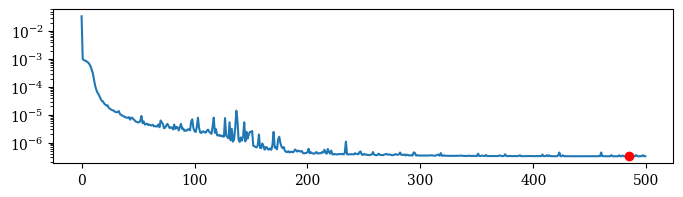

In [15]:
plt.figure(figsize=(8,2))
plt.plot(losses)
plt.yscale('log')
plt.scatter(best_epoch,losses[best_epoch], marker='o',c='red',zorder=2)
plt.show()